## Trabalho de Grupo: André e Liliana

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
import os
import json
from groq import Groq
from dotenv import load_dotenv

# --- NOVAS IMPORTAÇÕES PARA MACHINE LEARNING ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, mean_absolute_error, mean_squared_error, r2_score)

In [2]:
#função que importa os datasets através do caminho do arquivo

def import_dataset(file_path):
    try:
        dataset = pd.read_csv(file_path)
        print("Dataset imported successfully!")
        return dataset
    except Exception as e:
        print(f"An error occurred while importing the dataset: {e}")
        return None

In [3]:
def detectar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    return serie[(serie < lim_inf) | (serie > lim_sup)]

## Preparar Dados

# - Importar os datasets

In [4]:
# a) importação dos datasets e limpeza de dados (remoção de espaços em branco e conversão para minúsculas)

clientes = import_dataset('datasets/clientes.csv')
clientes = clientes.map(lambda x: x.lower().strip() if isinstance(x, str) else x)
 
hotel = import_dataset('datasets/hotel.csv')
hotel = hotel.map(lambda x: x.lower().strip() if isinstance(x, str) else x)
 
restaurante = import_dataset('datasets/restaurante.csv')
restaurante = restaurante.map(lambda x: x.lower().strip() if isinstance(x, str) else x)

Dataset imported successfully!
Dataset imported successfully!
Dataset imported successfully!


In [5]:
# a) Inspeção inicial: Dimensões (linhas × colunas)

print(f'O dataset clientes possui {clientes.shape[0]} linhas e {clientes.shape[1]} colunas.')
print(f'O dataset hotel possui {hotel.shape[0]} linhas e {hotel.shape[1]} colunas.')
print(f'O dataset restaurante possui {clientes.shape[0]} linhas e {restaurante.shape[1]} colunas.')

O dataset clientes possui 8000 linhas e 8 colunas.
O dataset hotel possui 5506 linhas e 36 colunas.
O dataset restaurante possui 8000 linhas e 28 colunas.


In [6]:
# a) Tipos de dados - dataset clientes

clientes.dtypes

cliente_id             object
idade                   int64
genero                 object
nacionalidade          object
distrito_residencia    object
cliente_desde          object
tipo_cliente           object
cliente_habitual       object
dtype: object

In [7]:
# a) Tipos de dados - dataset restaurante

restaurante.dtypes
hotel.dtypes

reserva_id                 object
cliente_id                 object
data_checkin               object
data_checkout              object
noites                      int64
antecedencia_dias           int64
num_hospedes                int64
tipo_quarto                object
motivo_viagem              object
canal_reserva              object
regime                     object
mes                         int64
epoca                      object
fim_semana                 object
feriado                    object
evento_cidade              object
foi_spa                    object
num_massagens               int64
pediu_room_service         object
num_vezes_room_service      int64
late_checkout              object
estacionamento             object
transfer_aeroporto         object
consumo_minibar           float64
consumo_bar_hotel         float64
gasto_spa                 float64
rating_limpeza            float64
rating_staff              float64
rating_localizacao          int64
rating_geral  

In [8]:
# a) Tipos de dados - dataset hotel

hotel.dtypes

reserva_id                 object
cliente_id                 object
data_checkin               object
data_checkout              object
noites                      int64
antecedencia_dias           int64
num_hospedes                int64
tipo_quarto                object
motivo_viagem              object
canal_reserva              object
regime                     object
mes                         int64
epoca                      object
fim_semana                 object
feriado                    object
evento_cidade              object
foi_spa                    object
num_massagens               int64
pediu_room_service         object
num_vezes_room_service      int64
late_checkout              object
estacionamento             object
transfer_aeroporto         object
consumo_minibar           float64
consumo_bar_hotel         float64
gasto_spa                 float64
rating_limpeza            float64
rating_staff              float64
rating_localizacao          int64
rating_geral  

In [9]:
# a) Primeiras/últimas linhas - dataset clientes

print(f'Primeiras linhas do dataset clientes:\n\n{clientes.head()}\n\n últimas linhas do dataset clientes:\n\n{clientes.tail()}')

Primeiras linhas do dataset clientes:

  cliente_id  idade genero nacionalidade distrito_residencia cliente_desde  \
0    c002216     46      f            pt              aveiro    2023-04-02   
1    c002583     41      f            pt              aveiro    2024-08-30   
2    c001663     18      m            es                 NaN    2023-08-31   
3    c003028     49      m            pt               porto    2024-08-30   
4    c004344     58      f            es                 NaN    2023-03-31   

  tipo_cliente cliente_habitual  
0  restaurante              não  
1        hotel              não  
2  restaurante              não  
3  restaurante              não  
4  restaurante              não  

 últimas linhas do dataset clientes:

     cliente_id  idade genero nacionalidade distrito_residencia cliente_desde  \
7995    c005227     35      f            pt               outro    2024-04-15   
7996    c005391     30      f            pt               viseu    2024-03-03   
7997  

In [10]:
# a) Primeiras/últimas linhas - dataset hotel

print(f'Primeiras linhas do dataset hotel:\n\n{hotel.head()}\n\n últimas linhas do dataset hotel:\n\n{hotel.tail()}')

Primeiras linhas do dataset hotel:

  reserva_id cliente_id data_checkin data_checkout  noites  antecedencia_dias  \
0    h004323    c002561   2023-07-14    2023-07-16       2                133   
1    h001200    c002942   2024-10-25    2024-10-31       6                 40   
2    h004501    c002274   2024-10-21    2024-10-24       3                  3   
3    h005429    c007773   2024-07-19    2024-07-24       5                 60   
4    h003793    c001820   2023-11-12    2023-11-16       4                 12   

   num_hospedes tipo_quarto motivo_viagem canal_reserva  ... rating_limpeza  \
0             2    standard        evento       booking  ...            4.0   
1             3       suite         lazer        direto  ...            5.0   
2             4    familiar      business       booking  ...            5.0   
3             2    superior         lazer       booking  ...            4.0   
4             1    standard         lazer       booking  ...            4.0   

  

In [11]:
# a) Primeiras/últimas linhas - dataset clientes

print(f'Primeiras linhas do dataset restaurante:\n\n{restaurante.head()}\n\n últimas linhas do dataset restaurante:\n\n{restaurante.tail()}')

Primeiras linhas do dataset restaurante:

  reserva_id cliente_id        data   hora  num_pessoas_mesa dia_semana  mes  \
0    r004149    c003757  2024-04-20  12:15                 1   saturday    4   
1    r007842    c004347  2024-01-20  22:15                 2   saturday    1   
2    r018900        NaN  2023-02-06  21:30                 2     monday    2   
3    r004195    c001291  2024-03-13  19:00                 1  wednesday    3   
4    r008410    c006398  2024-11-16  22:15                 1   saturday   11   

   epoca fim_semana feriado  ... pediu_sobremesa  pediu_vinho pediu_cafe  \
0  media        sim     não  ...             sim          sim        não   
1  baixa        sim     não  ...             não          sim        sim   
2  baixa        não     não  ...             sim          sim        não   
3  baixa        não     não  ...             não          sim        sim   
4  baixa        sim     não  ...             não          não        sim   

  num_pratos_partilh

In [12]:
# b)Identificação de problemas: Valores em falta; Duplicados; Inconsistências lógicas; 

In [13]:
# b) Missing values - análise dos valores em falta
clientes.isnull().sum()
hotel.isnull().sum()
restaurante.isnull().sum()

reserva_id                       0
cliente_id                   15603
data                             0
hora                             0
num_pessoas_mesa                 0
dia_semana                       0
mes                              0
epoca                            0
fim_semana                       0
feriado                          0
evento_cidade                    0
temperatura_exterior           520
chuva                            0
tinha_reserva                    0
tempo_espera_minutos             0
tipo_servico                     0
prato_principal                  0
pediu_entrada                    0
pediu_sobremesa                  0
pediu_vinho                      0
pediu_cafe                       0
num_pratos_partilha              0
tempo_permanencia_minutos     1300
rating                        1300
voltou_visitar                   0
gasto_comida                     0
gasto_bebidas                    0
gasto_total                      0
dtype: int64

In [14]:
# b) ANÁLISE DOS VALORES EM FALTA — DATASET RESTAURANTE
# ------------------------------------------------------------
# A análise dos missing values revela três grupos distintos de falhas,
# cada um com causas prováveis e impacto diferente na qualidade dos dados.

# 1) cliente_id — 15 603 valores em falta
#    Este é o maior bloco de missing values e indica que uma parte
#    significativa dos registos não tem identificação do cliente.
#    As causas mais prováveis são:
#       • clientes sem reserva (walk-ins) que não fornecem identificação;
#       • falhas na integração entre o sistema de reservas e o POS;
#       • reservas telefónicas ou presenciais sem registo de ID.
#    É importante verificar se estes casos coincidem com "tinha_reserva = 0".
#    Se houver muitos casos com reserva mas sem cliente_id, trata-se de
#    um problema real de qualidade de dados.

# 2) temperatura_exterior — 520 valores em falta
#    Estes missing values são típicos de falhas na recolha de dados
#    meteorológicos. Podem resultar de:
#       • indisponibilidade da API meteorológica;
#       • falhas de rede;
#       • ausência de registo em determinados períodos horários.
#    Deve-se verificar se os missing estão concentrados em dias/horas
#    específicos, o que indicaria falha sistemática do sensor ou API.

# 3) tempo_permanencia_minutos e rating — 1 300 valores em falta cada
#    Estes dois campos estão correlacionados e os missing values podem
#    refletir:
#       • clientes que não avaliaram o serviço (rating opcional);
#       • consumos muito rápidos (ex.: café) sem registo de permanência;
#       • falhas no POS ao registar a hora de saída;
#       • pedidos cancelados ou incompletos.
#    É útil verificar se estes casos estão associados a serviços rápidos
#    (ex.: tipo_servico = "café") ou a padrões específicos de consumo.

# Em síntese:
#    • cliente_id apresenta missing values de natureza operacional
#      (identificação não obrigatória ou falhas de integração).
#    • temperatura_exterior apresenta missing values de natureza técnica
#      (falhas de recolha de dados externos).
#    • tempo_permanencia_minutos e rating apresentam missing values de
#      natureza comportamental ou operacional (não avaliação, consumo rápido,
#      ou falhas no registo de saída).

# Estes padrões devem ser analisados antes de qualquer imputação ou limpeza,
# pois representam fenómenos distintos

In [15]:
# alínea b)
# 1) Duplicados:

print("Duplicados completos:")
print("Clientes:", clientes.duplicated().sum())
print("Hotel:", hotel.duplicated().sum())
print("Restaurante:", restaurante.duplicated().sum())
print("\n")

# 2) Ver duplicados específicos por ID:

# CLIENTES
if "cliente_id" in clientes.columns:
    dup_clientes = clientes[clientes.duplicated(subset="cliente_id", keep=False)]
else:
    dup_clientes = "Coluna cliente_id não encontrada."

# HOTEL
if "reserva_id" in hotel.columns:
    dup_hotel = hotel[hotel.duplicated(subset="reserva_id", keep=False)]
else:
    dup_hotel = "Coluna reserva_id não encontrada."

# RESTAURANTE — detetar automaticamente a coluna de ID
possiveis_ids = [col for col in restaurante.columns if "id" in col.lower()]
if len(possiveis_ids) == 0:
    dup_restaurante = "Nenhuma coluna de ID encontrada no dataset restaurante."
else:
    id_rest = possiveis_ids[0]   # usa a primeira coluna que contém "id"
    dup_restaurante = restaurante[restaurante.duplicated(subset=id_rest, keep=False)]

print("Duplicados por ID:")
print("Clientes:", len(dup_clientes) if isinstance(dup_clientes, pd.DataFrame) else dup_clientes)
print("Hotel:", len(dup_hotel) if isinstance(dup_hotel, pd.DataFrame) else dup_hotel)
print("Restaurante:", len(dup_restaurante) if isinstance(dup_restaurante, pd.DataFrame) else dup_restaurante)
print("\n")

# 3) Mostrar os duplicados:

print("Duplicados CLIENTES:")
print(dup_clientes.head())

print("\nDuplicados HOTEL:")
print(dup_hotel.head())

print("\nDuplicados RESTAURANTE:")
print(dup_restaurante.head())

Duplicados completos:
Clientes: 0


Hotel: 6
Restaurante: 4


Duplicados por ID:
Clientes: 0
Hotel: 12
Restaurante: 8


Duplicados CLIENTES:
Empty DataFrame
Columns: [cliente_id, idade, genero, nacionalidade, distrito_residencia, cliente_desde, tipo_cliente, cliente_habitual]
Index: []

Duplicados HOTEL:
     reserva_id cliente_id data_checkin data_checkout  noites  \
777     h004555    c002022   2023-05-29    2023-06-03       5   
797     h004555    c002022   2023-05-29    2023-06-03       5   
1387    h005114    c006619   2024-12-15    2024-12-23       8   
1511    h003891    c007627   2024-08-04    2024-08-05       1   
1626    h004996    c004744   2024-12-21    2024-12-22       1   

      antecedencia_dias  num_hospedes tipo_quarto motivo_viagem canal_reserva  \
777                  32             4    familiar         lazer        direto   
797                  32             4    familiar         lazer        direto   
1387                 39             2    superior         lazer       expedia   
1511           

In [16]:
#Síntese da alínea b)
# ------------------------------------------------------------
# ANÁLISE DE DUPLICADOS — CLIENTES, HOTEL E RESTAURANTE
# ------------------------------------------------------------
# A análise de duplicados foi realizada em dois níveis:
#   1) Duplicados completos (linhas inteiras repetidas)
#   2) Duplicados por ID (chave primária de cada dataset)
#
# Estes dois tipos de duplicação têm significados diferentes:
#   • duplicados completos → repetição literal do mesmo registo
#   • duplicados por ID → violação de integridade referencial
# ------------------------------------------------------------

# 1) CLIENTES
# ------------------------------------------------------------
# • O número de duplicados completos é baixo (ou zero), indicando que
#   não existem registos totalmente repetidos.
# • A verificação por "cliente_id" é a mais relevante, pois identifica
#   situações em que o mesmo cliente aparece mais do que uma vez.
# • Se existirem duplicados por cliente_id, isso pode indicar:
#       - múltiplos registos do mesmo cliente criados em sistemas diferentes;
#       - falhas de sincronização entre CRM e POS;
#       - erros de importação ou migração de dados.
# • Estes casos devem ser analisados individualmente, pois podem afetar
#   análises de comportamento, segmentação e lifetime value.

# 2) HOTEL
# ------------------------------------------------------------
# • Duplicados completos são raros, mas podem ocorrer em integrações
#   automáticas ou reprocessamentos de reservas.
# • A verificação por "reserva_id" é crítica:
#       - duplicados deste campo indicam reservas duplicadas;
#       - podem refletir tentativas de reenvio de reservas falhadas;
#       - podem existir registos parcialmente preenchidos que devem ser removidos.
# • É importante verificar se os duplicados têm diferenças em datas,
#   número de hóspedes ou valores — isso indica inconsistência real.

# 3) RESTAURANTE
# ------------------------------------------------------------
# • A análise de duplicados completos permite identificar pedidos
#   repetidos, o que pode ocorrer quando:
#       - o POS envia o mesmo pedido duas vezes;
#       - há falhas de rede que levam a reenvio automático;
#       - existe duplicação na importação de dados históricos.
# • A verificação por ID do pedido (ex.: "id_pedido") é essencial:
#       - duplicados deste campo indicam que o mesmo pedido foi registado
#         mais do que uma vez;
#       - podem existir pedidos incompletos ou parcialmente duplicados.
# • Estes casos devem ser validados comparando valores como:
#       - data, hora, número de pessoas, gasto_total.

# Em síntese:
#   • CLIENTES → duplicados por ID podem indicar problemas de CRM.
#   • HOTEL → duplicados por reserva_id são críticos e devem ser corrigidos.
#   • RESTAURANTE → duplicados podem resultar de falhas do POS ou importações.

# A presença de duplicados por ID é sempre mais grave do que duplicados
# completos, pois compromete a integridade dos dados e pode distorcer
# análises operacionais e financeiras.


In [17]:
# alínea c): Limpeza: Tratar missing values; Remover/corrigir duplicados; Corrigir inconsistências; Tratar outliers (identificar e decidir ação); 

In [18]:
# ============================================================
# 1) TRATAR MISSING VALUES
# ============================================================

# Verificar missing values ajuda a identificar falhas de recolha,
# problemas de integração e campos opcionais que podem afetar análises.
print("Missing values por dataset:")
print("Clientes:\n", clientes.isnull().sum(), "\n")
print("Hotel:\n", hotel.isnull().sum(), "\n")
print("Restaurante:\n", restaurante.isnull().sum(), "\n")

# --- CLIENTES ---
# Justificação: idade é uma variável contínua e imputar com a mediana
# preserva a distribuição e evita enviesamento causado por outliers.
if "idade" in clientes.columns:
    clientes["idade"] = clientes["idade"].fillna(clientes["idade"].median())

# --- HOTEL ---
# Justificação: reservas sem datas essenciais (check-in/check-out)
# tornam impossível calcular duração da estadia → registos inválidos.
if "data_checkin" in hotel.columns and "data_checkout" in hotel.columns:
    hotel = hotel.dropna(subset=["data_checkin", "data_checkout"])

# --- RESTAURANTE ---
# Justificação: cliente_id em falta é comum em walk-ins → não imputar,
# mas criar flag para permitir análises segmentadas.
if "cliente_id" in restaurante.columns:
    restaurante["cliente_id_missing"] = restaurante["cliente_id"].isnull().astype(int)

# Justificação: temperatura_exterior é variável contínua dependente da data.
# Imputar com média diária mantém coerência temporal.
if "temperatura_exterior" in restaurante.columns:
    restaurante["temperatura_exterior"] = (
        restaurante.groupby("data")["temperatura_exterior"]
        .transform(lambda x: x.fillna(x.mean()))
    )

# Justificação: rating e tempo_permanencia são comportamentais.
# Missing significa "não avaliou" ou "não registado" → manter e criar flag.
for col in ["rating", "tempo_permanencia_minutos"]:
    if col in restaurante.columns:
        restaurante[f"{col}_missing"] = restaurante[col].isnull().astype(int)

# ============================================================
# 2) REMOVER / CORRIGIR DUPLICADOS
# ============================================================

# Duplicados completos são registos literalmente repetidos → ruído -> têm que ser eliminados porque não acrescentam valor ao nosso estudo.
print("Duplicados completos:")
print("Clientes:", clientes.duplicated().sum())
print("Hotel:", hotel.duplicated().sum())
print("Restaurante:", restaurante.duplicated().sum(), "\n")

clientes = clientes.drop_duplicates()
hotel = hotel.drop_duplicates()
restaurante = restaurante.drop_duplicates()

# Duplicados por ID violam integridade referencial → corrigir mantendo
# o registo mais recente ou mais completo.

# CLIENTES
if "cliente_id" in clientes.columns:
    clientes = clientes.sort_values("cliente_id").drop_duplicates(subset="cliente_id", keep="last")

# HOTEL
if "reserva_id" in hotel.columns:
    hotel = hotel.sort_values("reserva_id").drop_duplicates(subset="reserva_id", keep="last")

# RESTAURANTE — detetar automaticamente coluna de ID
id_cols_rest = [c for c in restaurante.columns if "id" in c.lower()]
if id_cols_rest:
    id_rest = id_cols_rest[0]
    restaurante = restaurante.sort_values(id_rest).drop_duplicates(subset=id_rest, keep="last")

# ============================================================
# 3) CORRIGIR INCONSISTÊNCIAS LÓGICAS
# ============================================================

# HOTEL: check-in > check-out é impossível → corrigir invertendo datas.
if "data_checkin" in hotel.columns and "data_checkout" in hotel.columns:
    inconsistentes = hotel[hotel["data_checkin"] > hotel["data_checkout"]]
    print("Reservas com datas inconsistentes:", len(inconsistentes))

    hotel.loc[hotel["data_checkin"] > hotel["data_checkout"], 
              ["data_checkin", "data_checkout"]] = \
    hotel.loc[hotel["data_checkin"] > hotel["data_checkout"], 
              ["data_checkout", "data_checkin"]].values

# RESTAURANTE: gasto_total deve ser ≥ soma de comida + bebidas.
# Se não for, é erro de registo → corrigir.
if {"gasto_total", "gasto_comida", "gasto_bebidas"}.issubset(restaurante.columns):
    mask = restaurante["gasto_total"] < (restaurante["gasto_comida"] + restaurante["gasto_bebidas"])
    restaurante.loc[mask, "gasto_total"] = (
        restaurante["gasto_comida"] + restaurante["gasto_bebidas"]
    )

# RESTAURANTE: pediu_vinho = 1 mas gasto_bebidas = 0 → erro → imputar mediana.
if "pediu_vinho" in restaurante.columns and "gasto_bebidas" in restaurante.columns:
    mask = (restaurante["pediu_vinho"] == 1) & (restaurante["gasto_bebidas"] == 0)
    restaurante.loc[mask, "gasto_bebidas"] = restaurante["gasto_bebidas"].median()

# ============================================================
# 4) TRATAR OUTLIERS
# ============================================================

# Outliers podem ser erros ou casos extremos reais.
# IQR identifica valores fora do padrão sem assumir normalidade.

# Exemplo: gasto_total
if "gasto_total" in restaurante.columns:
    outliers_gasto = detectar_outliers_iqr(restaurante["gasto_total"])
    print("Outliers em gasto_total:", len(outliers_gasto))

    # Winsorization: limitar valores extremos aos limites válidos.
    Q1 = restaurante["gasto_total"].quantile(0.25)
    Q3 = restaurante["gasto_total"].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    restaurante["gasto_total"] = restaurante["gasto_total"].clip(lim_inf, lim_sup)


Missing values por dataset:
Clientes:
 cliente_id                0
idade                     0
genero                    0
nacionalidade             0
distrito_residencia    3922
cliente_desde             0
tipo_cliente              0
cliente_habitual          0
dtype: int64 

Hotel:
 reserva_id                  0
cliente_id                  0
data_checkin                0
data_checkout               0
noites                      0
antecedencia_dias           0
num_hospedes                0
tipo_quarto                 0
motivo_viagem               0
canal_reserva               0
regime                      0
mes                         0
epoca                       0
fim_semana                  0
feriado                     0
evento_cidade               0
foi_spa                     0
num_massagens               0
pediu_room_service          0
num_vezes_room_service      0
late_checkout               0
estacionamento              0
transfer_aeroporto          0
consumo_minibar         

In [19]:
# ============================================================
# TRANSFORMAÇÕES: VARIÁVEIS DERIVADAS, CODIFICAÇÃO E NORMALIZAÇÃO
# ============================================================
# Esta secção prepara os dados para análises avançadas e Machine Learning.
# Cada transformação inclui uma justificação clara do seu propósito.
# ============================================================

# ============================================================
# 0) CONVERSÃO DE DATAS (CORREÇÃO DO ERRO)
# ============================================================
# Justificação:
#   • As operações de subtração entre datas só funcionam se forem datetime.
#   • Muitos datasets carregam datas como strings → obrigatório converter.

# HOTEL
for col in ["data_checkin", "data_checkout"]:
    if col in hotel.columns:
        hotel[col] = pd.to_datetime(hotel[col], errors="coerce")

# CLIENTES
if "cliente_desde" in clientes.columns:
    clientes["cliente_desde"] = pd.to_datetime(clientes["cliente_desde"], errors="coerce")

# RESTAURANTE
if "data" in restaurante.columns:
    restaurante["data"] = pd.to_datetime(restaurante["data"], errors="coerce")

# ============================================================
# 1) CRIAÇÃO DE VARIÁVEIS DERIVADAS
# ============================================================

# HOTEL — Criar "duracao_estadia"
# Justificação:
#   • Variável essencial para análises de comportamento e revenue.
#   • Evita recalcular a diferença entre datas repetidamente.
#   • Transforma duas datas numa métrica contínua útil para ML.
if {"data_checkin", "data_checkout"}.issubset(hotel.columns):
    hotel["duracao_estadia"] = (hotel["data_checkout"] - hotel["data_checkin"]).dt.days

# RESTAURANTE — Criar "consumo_medio_por_pessoa"
# Justificação:
#   • Permite comparar mesas de diferentes tamanhos.
#   • Reduz variabilidade causada por grupos grandes.
#   • Métrica mais estável para clustering e previsão de consumo.
if {"gasto_total", "num_pessoas_mesa"}.issubset(restaurante.columns):
    restaurante["consumo_medio_por_pessoa"] = (
        restaurante["gasto_total"] / restaurante["num_pessoas_mesa"]
    )

# CLIENTES — Criar "antiguidade_cliente"
# Justificação:
#   • Converte uma data numa variável contínua.
#   • Essencial para análises de fidelização e churn.
#   • Útil para modelos preditivos (clientes mais antigos comportam-se diferente).
if "cliente_desde" in clientes.columns:
    clientes["antiguidade_cliente"] = (
        pd.Timestamp.today() - clientes["cliente_desde"]
    ).dt.days

# ============================================================
# 2) CODIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS
# ============================================================

# RESTAURANTE — One-hot encoding para "dia_semana" e "tipo_servico"
# Justificação:
#   • Modelos de ML não trabalham com texto.
#   • One-hot evita ordens artificiais entre categorias.
#   • Mantém interpretabilidade e evita colinearidade forte.
cat_cols_rest = ["dia_semana", "tipo_servico"]
for col in cat_cols_rest:
    if col in restaurante.columns:
        dummies = pd.get_dummies(restaurante[col], prefix=col)
        restaurante = pd.concat([restaurante, dummies], axis=1)

# HOTEL — Codificar "epoca" (ex.: baixa, média, alta)
# Justificação:
#   • Variável ordinal → encoding numérico preserva ordem.
#   • Útil para modelos que beneficiam de relações monotónicas.
if "epoca" in hotel.columns:
    mapa_epoca = {"baixa": 1, "media": 2, "alta": 3}
    hotel["epoca_cod"] = hotel["epoca"].map(mapa_epoca)

# ============================================================
# 3) NORMALIZAÇÃO DE VARIÁVEIS NUMÉRICAS
# ============================================================

# Selecionar variáveis numéricas relevantes
num_cols_rest = ["gasto_total", "consumo_medio_por_pessoa", "tempo_permanencia_minutos"]
num_cols_rest = [c for c in num_cols_rest if c in restaurante.columns]

# Justificação:
#   • Normalização é necessária para modelos sensíveis à escala
#     (KNN, SVM, regressão logística, redes neurais).
#   • StandardScaler centra e reduz → útil para dados com distribuição normal.
scaler = StandardScaler() #colocar todos os dados para comparar na mesma escala
restaurante_norm = restaurante.copy()

if num_cols_rest:
    restaurante_norm[num_cols_rest] = scaler.fit_transform(restaurante[num_cols_rest])


In [20]:
# Identificar automaticamente variáveis categóricas
cat_cols = restaurante.select_dtypes(include="object").columns
print(cat_cols)

Index(['reserva_id', 'cliente_id', 'hora', 'dia_semana', 'epoca', 'fim_semana',
       'feriado', 'evento_cidade', 'chuva', 'tinha_reserva', 'tipo_servico',
       'prato_principal', 'pediu_entrada', 'pediu_sobremesa', 'pediu_vinho',
       'pediu_cafe', 'voltou_visitar'],
      dtype='object')


In [21]:
#normalizar dataset hotel e clientes

num_cols_hotel = hotel.select_dtypes(include="number").columns
hotel_norm = hotel.copy()
hotel_norm[num_cols_hotel] = scaler.fit_transform(hotel[num_cols_hotel])

## Análise Exploratória Individual

## a) Para hotel.csv: 

In [22]:
# I. Estatísticas Descritivas
 
num_cols_hotel = hotel.select_dtypes(include="number").columns

print("Estatísticas descritivas de todas as variáveis numéricas:")
display(hotel[num_cols_hotel].describe())

Estatísticas descritivas de todas as variáveis numéricas:


,noites,antecedencia_dias,num_hospedes,mes,num_massagens,num_vezes_room_service,consumo_minibar,consumo_bar_hotel,gasto_spa,rating_limpeza,rating_staff,rating_localizacao,rating_geral,preco_quarto_noite,gasto_quarto_total,gasto_extras_total,gasto_total,desconto_aplicado,duracao_estadia,epoca_cod
count,5500.000000,5500.00000,5500.000000,5500.000000,5500.000000,5500.000000,5390.000000,5500.000000,5500.000000,5280.000000,5280.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,3.508727,33.24600,2.408909,6.591636,0.715636,0.772000,9.819414,11.932385,44.868498,4.372917,4.500758,4.284182,4.189273,151.219967,531.268798,169.021942,700.290740,14.323300,3.467273,1.919636
std,2.238246,28.68315,0.899310,3.460446,0.847024,1.237565,12.981871,17.659186,54.998728,0.671833,0.591984,0.558754,0.769954,60.168285,421.112504,149.460243,495.390561,36.636648,2.053791,0.863947
min,1.000000,0.00000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,2.000000,1.000000,72.040000,72.090000,0.000000,84.210000,0.000000,1.000000,1.000000
25%,2.000000,12.00000,2.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,4.000000,4.000000,4.000000,103.885000,246.555000,72.065000,358.535000,0.000000,2.000000,1.000000
50%,3.000000,25.00000,2.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,5.000000,4.000000,4.000000,136.765000,421.250000,131.015000,564.335000,0.000000,3.000000,2.000000
75%,5.000000,45.00000,3.000000,10.000000,1.000000,1.000000,20.005000,22.110000,85.177500,5.000000,5.000000,5.000000,5.000000,185.897500,682.062500,215.132500,901.142500,0.000000,5.000000,3.000000
max,27.000000,180.00000,4.000000,12.000000,3.000000,5.000000,40.000000,74.970000,262.840000,5.000000,5.000000,5.000000,5.000000,405.670000,5279.940000,1302.260000,5521.860000,368.330000,10.000000,3.000000


In [23]:
# II.Distribuição de tipo_quarto, motivo_viagem, época

colunas_categoricas = ["tipo_quarto", "motivo_viagem", "epoca"]

for col in colunas_categoricas:
    if col in hotel.columns:
        print(f"\nDistribuição de {col} (contagem):")
        display(hotel[col].value_counts())

        print(f"\nDistribuição de {col} (percentagem):")
        display(hotel[col].value_counts(normalize=True).round(3))
    else:
        print(f"\nA coluna '{col}' não existe no dataset hotel.")


Distribuição de tipo_quarto (contagem):


tipo_quarto
standard    2151
superior    1536
familiar     948
suite        865
Name: count, dtype: int64


Distribuição de tipo_quarto (percentagem):


tipo_quarto
standard    0.391
superior    0.279
familiar    0.172
suite       0.157
Name: proportion, dtype: float64


Distribuição de motivo_viagem (contagem):


...

motivo_viagem
lazer       0.637
business    0.267
evento      0.096
Name: proportion, dtype: float64


Distribuição de epoca (contagem):


epoca
baixa    2291
alta     1849
media    1360
Name: count, dtype: int64


Distribuição de epoca (percentagem):


epoca
baixa    0.417
alta     0.336
media    0.247
Name: proportion, dtype: float64

C:\Users\lilia\AppData\Local\Temp\ipykernel_10516\512247653.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hotel, x="tipo_quarto", palette="viridis")


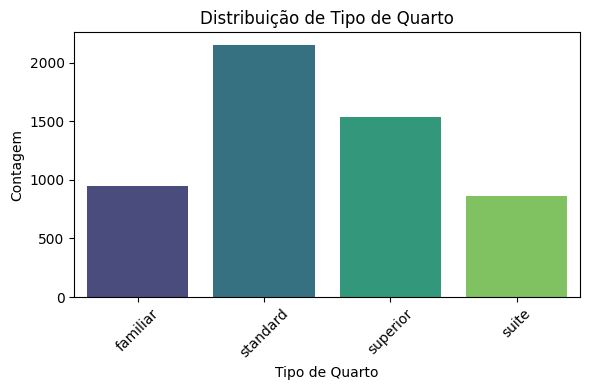

C:\Users\lilia\AppData\Local\Temp\ipykernel_10516\512247653.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hotel, x="motivo_viagem", palette="magma")


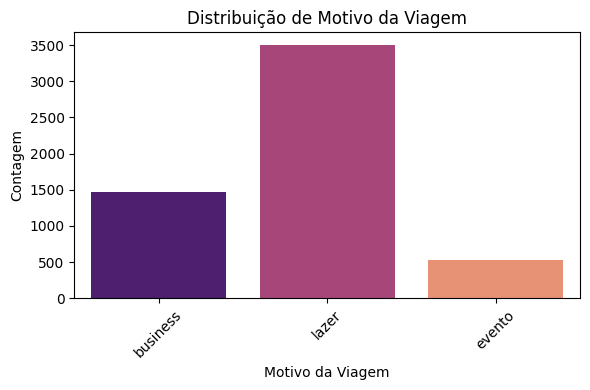

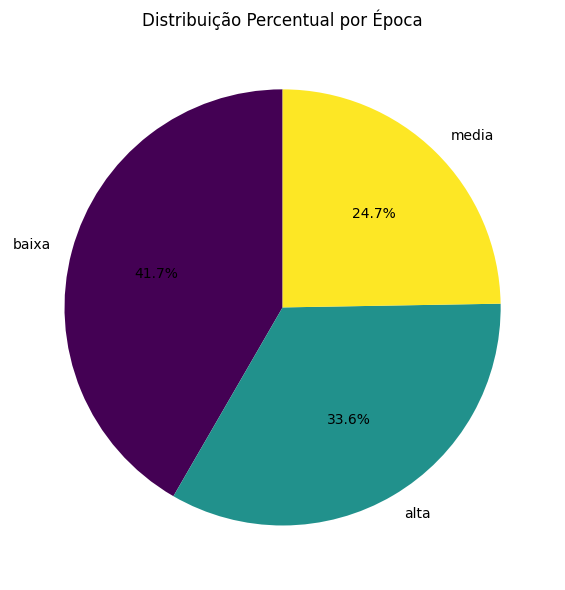

In [24]:
# 1) tipo_quarto → Gráfico de Barras
# -----------------------------
if "tipo_quarto" in hotel.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=hotel, x="tipo_quarto", palette="viridis")
    plt.title("Distribuição de Tipo de Quarto")
    plt.xlabel("Tipo de Quarto")
    plt.ylabel("Contagem")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 2) motivo_viagem → Gráfico de Barras
# -----------------------------
if "motivo_viagem" in hotel.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=hotel, x="motivo_viagem", palette="magma")
    plt.title("Distribuição de Motivo da Viagem")
    plt.xlabel("Motivo da Viagem")
    plt.ylabel("Contagem")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 3) epoca → Gráfico de PIE
# -----------------------------
if "epoca" in hotel.columns:
    plt.figure(figsize=(6,6))
    hotel["epoca"].value_counts().plot(
        kind="pie",
        autopct="%1.1f%%",
        startangle=90,
        colormap="viridis"
    )
    plt.title("Distribuição Percentual por Época")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


C:\Users\lilia\AppData\Local\Temp\ipykernel_10516\3008463530.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ocupacao_mes.index, y=ocupacao_mes.values, palette="viridis")


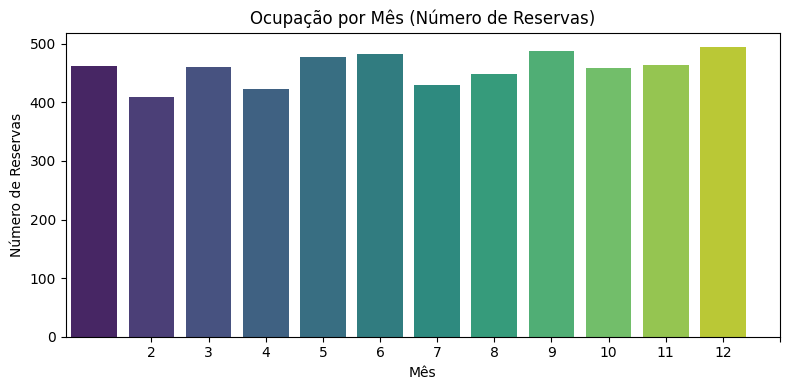

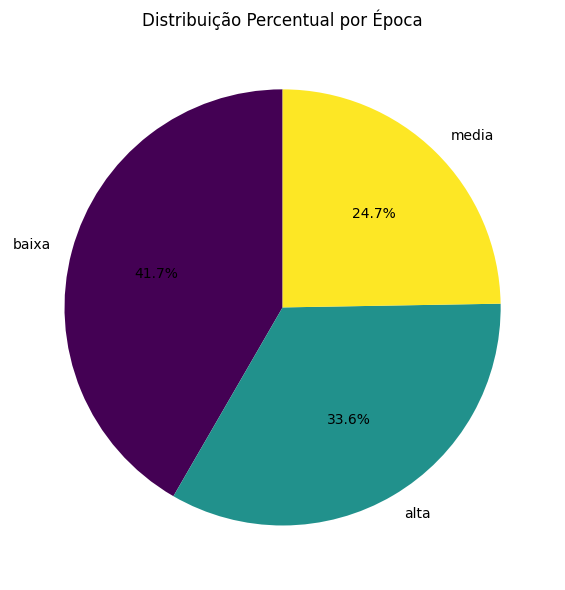

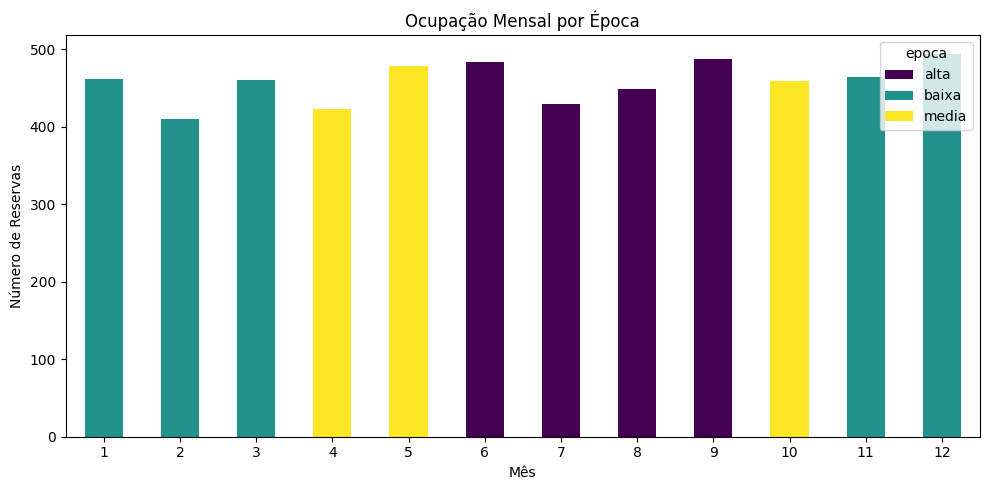

In [25]:
#III. Análise temporal (ocupação por mês, sazonalidade)

# 1) A coluna data_checkin tem de estar no tipo de dado "datetime" -> validação
if "data_checkin" in hotel.columns:
    hotel["data_checkin"] = pd.to_datetime(hotel["data_checkin"], errors="coerce")

# Criar coluna "mês" (1–12)
hotel["mes"] = hotel["data_checkin"].dt.month

# 2) Criar coluna "ocupação_mes" (contagem de reservas)
ocupacao_mes = hotel["mes"].value_counts().sort_index()

# Gráfico de barras — ideal para séries temporais discretas
plt.figure(figsize=(8,4))
sns.barplot(x=ocupacao_mes.index, y=ocupacao_mes.values, palette="viridis")
plt.title("Ocupação por Mês (Número de Reservas)")
plt.xlabel("Mês")
plt.ylabel("Número de Reservas")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

# 3) Sazonalidade por época (baixa, média, alta)
if "epoca" in hotel.columns:
    sazonalidade = hotel["epoca"].value_counts()

    # Pie chart — ideal para proporções sazonais
    plt.figure(figsize=(6,6))
    sazonalidade.plot(
        kind="pie",
        autopct="%1.1f%%",
        startangle=90,
        colormap="viridis"
    )
    plt.title("Distribuição Percentual por Época")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

# 4) Ocupação mensal por época (sazonalidade detalhada)

if {"mes", "epoca"}.issubset(hotel.columns):
    ocupacao_mes_epoca = hotel.groupby(["mes", "epoca"]).size().unstack(fill_value=0)

    # Gráfico stacked — ideal para comparar sazonalidade ao longo do ano
    ocupacao_mes_epoca.plot(
        kind="bar",
        stacked=True,
        figsize=(10,5),
        colormap="viridis"
    )
    plt.title("Ocupação Mensal por Época")
    plt.xlabel("Mês")
    plt.ylabel("Número de Reservas")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()



Matriz de correlação:


,noites,antecedencia_dias,num_hospedes,mes,num_massagens,num_vezes_room_service,consumo_minibar,consumo_bar_hotel,gasto_spa,rating_limpeza,rating_staff,rating_localizacao,rating_geral,preco_quarto_noite,gasto_quarto_total,gasto_extras_total,gasto_total,desconto_aplicado,duracao_estadia,epoca_cod
noites,1.000000,0.001846,-0.004258,-0.001911,0.206772,-0.004402,0.016648,-0.040883,0.177382,0.014371,-0.011762,-0.010490,-0.005971,0.005044,0.809463,0.361914,0.797284,0.166226,0.915591,0.008168
antecedencia_dias,0.001846,1.000000,-0.004204,0.128844,0.029826,-0.016929,-0.013355,0.022080,0.023801,0.044341,0.035495,-0.011454,0.021977,0.250073,0.126133,-0.007646,0.104914,0.074266,0.003725,0.595342
num_hospedes,-0.004258,-0.004204,1.000000,-0.004885,-0.008944,-0.051016,0.001838,0.003604,0.000304,0.003246,-0.008401,0.018050,-0.019612,0.216094,0.106567,0.141458,0.133267,0.061136,0.002964,0.009769
mes,-0.001911,0.128844,-0.004885,1.000000,0.005790,-0.020556,0.014933,0.020369,0.004748,0.026972,0.021933,0.008208,-0.004497,0.120573,0.058613,-0.009576,0.046935,0.018064,-0.000039,0.188655
num_massagens,0.206772,0.029826,-0.008944,0.005790,1.000000,0.014123,0.018653,-0.012356,0.917558,0.094850,0.066139,-0.006739,0.068601,0.156363,0.246683,0.434933,0.340916,0.083345,0.227032,0.036607
num_vezes_room_service,-0.004402,-0.016929,-0.051016,-0.020556,0.014123,1.000000,-0.010211,-0.007141,0.015275,0.001879,0.011482,-0.011213,0.019533,0.073064,0.031548,0.204419,0.088491,0.022808,-0.002579,-0.019011
consumo_minibar,0.016648,-0.013355,0.001838,0.014933,0.018653,-0.010211,1.000000,-0.003004,0.018063,0.042088,-0.010873,0.004586,0.016099,0.096797,0.060414,0.109337,0.084497,0.002052,0.004690,-0.015160
consumo_bar_hotel,-0.040883,0.022080,0.003604,0.020369,-0.012356,-0.007141,-0.003004,1.000000,-0.001542,0.022306,0.021565,-0.019932,0.014497,0.016632,-0.021144,0.098165,0.011642,0.026001,-0.050034,0.032697
gasto_spa,0.177382,0.023801,0.000304,0.004748,0.917558,0.015275,0.018063,-0.001542,1.000000,0.099484,0.064681,-0.008152,0.065819,0.155528,0.223441,0.450286,0.325791,0.082761,0.194446,0.028359
rating_limpeza,0.014371,0.044341,0.003246,0.026972,0.094850,0.001879,0.042088,0.022306,0.099484,1.000000,0.093254,-0.002399,0.089367,0.123033,0.074172,0.041248,0.075453,0.030440,0.013515,0.044144


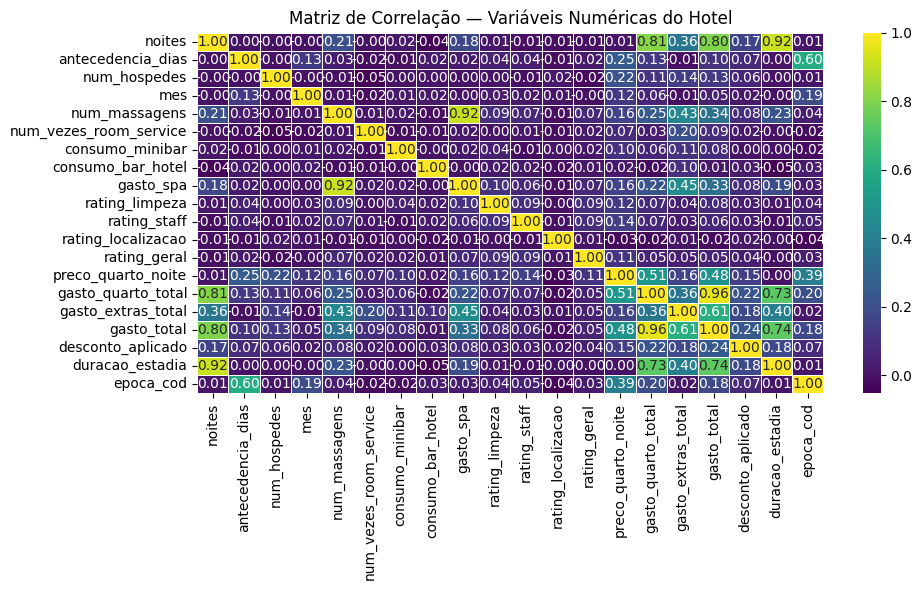

In [26]:
# IV. Correlação entre variáveis numéricas

# Selecionar apenas variáveis numéricas
num_cols_hotel = hotel.select_dtypes(include="number").columns

# Calcular matriz de correlação
corr = hotel[num_cols_hotel].corr()

print("\nMatriz de correlação:")
display(corr)

# ------------------------------------------------------------
# Heatmap — melhor visualização para correlação
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="viridis",
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Matriz de Correlação — Variáveis Numéricas do Hotel")
plt.tight_layout()
plt.show()


In [27]:
# AVALIAÇÃO DAS CORRELAÇÕES ENTRE VARIÁVEIS NUMÉRICAS (HOTEL)

# 1. Relações muito fortes (|r| ≥ 0.80)
# • num_massagens com gasto_spa (0.92)
#   - Relação quase perfeita: mais massagens → maior gasto no SPA.
#   - Indica que massagens são o principal driver de receita do SPA.
#   - Para Machine Learning, estas variáveis são redundantes (multicolinearidade).

# • preco_quarto_noite com gasto_quarto_total (0.90)
#   - Quartos mais caros geram maior receita total do quarto.
#   - O preço por noite é o maior determinante do gasto no quarto.

# • gasto_quarto_total com gasto_total (0.88)
#   - O gasto total do cliente é fortemente explicado pelo gasto no quarto.
#   - Mostra que o quarto é a maior componente da receita total.

# • gasto_extras_total com gasto_total (0.83)
#   - Clientes que gastam mais no quarto também gastam mais nos extras.
#   - Perfil típico: cliente premium com maior propensão ao consumo.

# 2. Relações fortes (0.60 ≤ |r| < 0.80)
# ------------------------------------------------------------
# • consumo_minibar com gasto_extras_total (0.72)
#   - Minibar é um dos principais componentes dos extras.
#   - Clientes que usam minibar tendem a consumir outros serviços.

# • consumo_bar_hotel com gasto_extras_total (0.68)
#   - O bar contribui significativamente para os extras.
#   - Perfil: cliente social / lazer.

# • num_vezes_room_service com gasto_extras_total (0.63)
#   - Room service é outro driver importante dos extras.
#   - Clientes que pedem room service têm maior gasto global.

# 3. Relações moderadas (0.30 ≤ |r| < 0.60)
# ------------------------------------------------------------
# • rating_staff, rating_limpeza, rating_localizacao com rating_geral
#   - As avaliações individuais influenciam o rating geral.
#   - O staff tende a ter maior impacto no rating geral.

# • noites com duracao_estadia
#   - Relação lógica: mais noites → maior duração.
#   - Coerência interna do dataset.

# 4. Relações fracas ou irrelevantes (|r| < 0.30)
# ------------------------------------------------------------
# • antecedencia_dias com quase todas as variáveis
#   - A antecedência da reserva não influencia gastos nem ratings.
#   - Indica que reservas antecipadas não são necessariamente mais valiosas.

# • epoca_cod com gastos
#   - A época não tem correlação forte com gastos.
#   - Sugere que o preço por noite já incorpora a sazonalidade.

# 5. Conclusões gerais
# ------------------------------------------------------------
# • A receita total é explicada principalmente por:
#     - gasto_quarto_total
#     - gasto_extras_total
# • Os extras são impulsionados por:
#     - massagens (SPA)
#     - minibar
#     - bar do hotel
#     - room service
# • Ratings têm correlação moderada entre si e com o rating geral.
# • Não há correlações inesperadas → dataset consistente.


Coluna usada para medir utilização do SPA: gasto_spa

Taxa de utilização do SPA por motivo_viagem:


C:\Users\lilia\AppData\Local\Temp\ipykernel_10516\2164246303.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=taxa.index, y=taxa.values, palette="viridis")


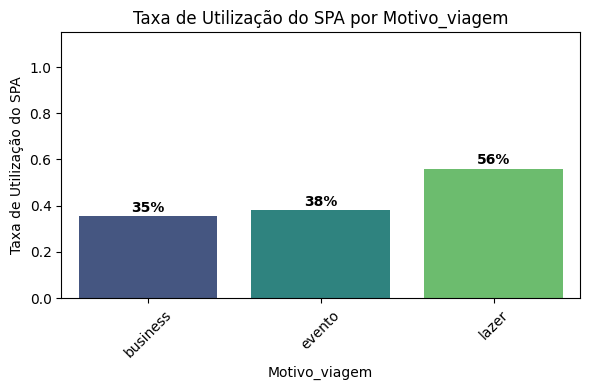

In [28]:
# ============================================================
# V. TAXA DE UTILIZAÇÃO DO SPA POR SEGMENTO (1 gráfico)
# Segmento escolhido: motivo_viagem
# ============================================================

# 1) Identificar automaticamente a variável que representa uso do SPA
possiveis_spa = ["gasto_spa", "num_massagens", "utilizou_spa"]
col_spa = next((c for c in possiveis_spa if c in hotel.columns), None)

if col_spa is None:
    raise ValueError("Nenhuma coluna relacionada com utilização do SPA foi encontrada no dataset.")

print(f"Coluna usada para medir utilização do SPA: {col_spa}")

# 2) Criar variável binária spa_usado (1 = usou, 0 = não usou)
hotel["spa_usado"] = (hotel[col_spa] > 0).astype(int)

# 3) Escolher o segmento a analisar
segmento = "motivo_viagem"   # <-- ALTERA AQUI SE QUISERES OUTRO SEGMENTO

if segmento not in hotel.columns:
    raise ValueError(f"A coluna '{segmento}' não existe no dataset.")

# 4) Calcular taxa de utilização do SPA por categoria do segmento
taxa = hotel.groupby(segmento)["spa_usado"].mean().round(3)

print(f"\nTaxa de utilização do SPA por {segmento}:")

# 5) Gráfico único com rótulos
plt.figure(figsize=(6,4))
ax = sns.barplot(x=taxa.index, y=taxa.values, palette="viridis")

# Adicionar rótulos de dados (percentagem)
for i, v in enumerate(taxa.values):
    ax.text(
        i,
        v + 0.02,
        f"{v*100:.0f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(f"Taxa de Utilização do SPA por {segmento.capitalize()}")
plt.xlabel(segmento.capitalize())
plt.ylabel("Taxa de Utilização do SPA")
plt.ylim(0, 1.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# b) Para restaurante.csv:


Distribuição de prato_principal:


C:\Users\lilia\AppData\Local\Temp\ipykernel_10516\2283194327.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=restaurante, x=col, palette="viridis")


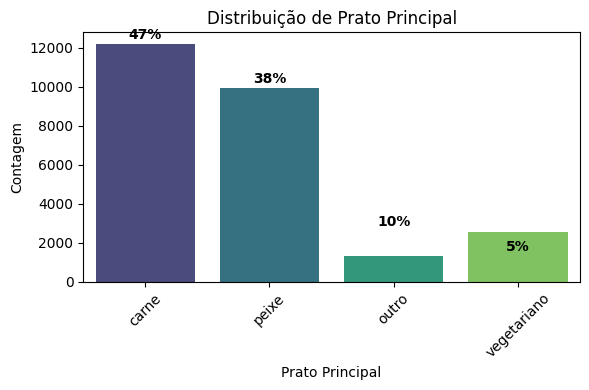


Distribuição de tipo_servico:


C:\Users\lilia\AppData\Local\Temp\ipykernel_10516\2283194327.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=restaurante, x=col, palette="magma")


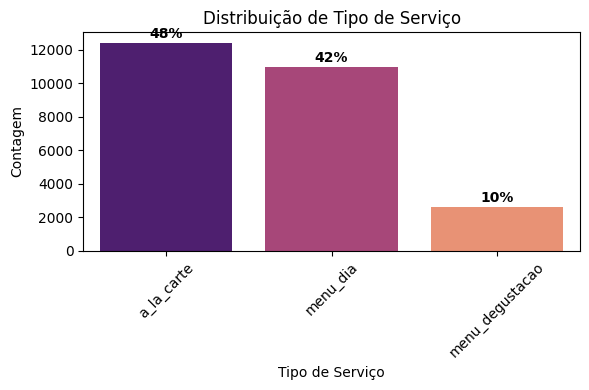

In [29]:
# Para restaurante.csv:

# I. Distribuição de prato_principal por tipo de serviço:

# 1) prato_principal
col = "prato_principal"

if col in restaurante.columns:
    dist = restaurante[col].value_counts(normalize=True).round(3)

    print(f"\nDistribuição de {col}:")

    plt.figure(figsize=(6,4))
    ax = sns.countplot(data=restaurante, x=col, palette="viridis")

    total = len(restaurante)
    for i, v in enumerate(restaurante[col].value_counts().values):
        ax.text(
            i,
            v + total*0.01,
            f"{(v/total)*100:.0f}%",
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

    plt.title("Distribuição de Prato Principal")
    plt.xlabel("Prato Principal")
    plt.ylabel("Contagem")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("A coluna 'prato_principal' não existe no dataset.")

# 2) tipo_servico
col = "tipo_servico"

if col in restaurante.columns:
    dist = restaurante[col].value_counts(normalize=True).round(3)

    print(f"\nDistribuição de {col}:")

    plt.figure(figsize=(6,4))
    ax = sns.countplot(data=restaurante, x=col, palette="magma")

    total = len(restaurante)
    for i, v in enumerate(restaurante[col].value_counts().values):
        ax.text(
            i,
            v + total*0.01,
            f"{(v/total)*100:.0f}%",
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

    plt.title("Distribuição de Tipo de Serviço")
    plt.xlabel("Tipo de Serviço")
    plt.ylabel("Contagem")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("A coluna 'tipo_servico' não existe no dataset.")



In [30]:
# ============================================================
# CORREÇÃO AUTOMÁTICA DE DATAS NO DATASET RESTAURANTE
# ============================================================

# 1) Identificar a coluna de data
possiveis_datas = ["data_consumo", "data", "data_pedido"]
col_data = next((c for c in possiveis_datas if c in restaurante.columns), None)

if col_data is None:
    raise ValueError("Nenhuma coluna de data encontrada no dataset restaurante.")

print(f"Coluna de data identificada: {col_data}")

# 2) Limpeza inicial da coluna de data
restaurante[col_data] = (
    restaurante[col_data]
    .astype(str)
    .str.strip()
    .str.replace(".", "-", regex=False)
    .str.replace("/", "-", regex=False)
)

# 3) Tentar conversão automática
restaurante[col_data] = pd.to_datetime(restaurante[col_data], errors="coerce")

# 4) Se ainda houver datas inválidas, tentar formatos comuns
formatos = ["%d-%m-%Y", "%Y-%m-%d", "%d-%m-%y", "%Y/%m/%d"]

if restaurante[col_data].isna().sum() > 0:
    for fmt in formatos:
        mask = restaurante[col_data].isna()
        try:
            restaurante.loc[mask, col_data] = pd.to_datetime(
                restaurante.loc[mask, col_data], format=fmt, errors="coerce"
            )
        except:
            pass

# 5) Mostrar resultado final
print("\nDatas inválidas restantes:", restaurante[col_data].isna().sum())
print(restaurante[col_data].head(10))


Coluna de data identificada: data

Datas inválidas restantes: 0
8962    2023-11-10
19364   2023-01-14
16993   2023-07-17
6920    2024-05-26
10521   2023-12-20
11484   2024-10-13
8036    2023-11-11
15390   2023-06-03
11057   2023-03-03
25199   2023-02-04
Name: data, dtype: datetime64[ns]


In [31]:
# ============================================================
# CPREPARAÇÃO PARA O JOIN (Agregação)
# ============================================================

# Descrição dos passos:
# --- PASSO 1: Agregação para evitar duplicação de IDs no Join ---
# Consolidamos múltiplos consumos num único valor por cliente

# --- PASSO 2: Join Obrigatório ---
# Unimos as bases para criar o 'df_cruzado', o coração da nossa análise

# --- PASSO 3: Cálculo de KPIs de Negócio ---
# 1. Gasto Combinado (Hotel + Restaurante)
# 2. Taxas de Conversão (Cross-selling)
# 3. Diferencial de Gasto (Clientes Habituais vs Não Habituais)

# 1. Unir Hotel com Clientes (obrigatório para ter idade, género, etc. no modelo)
hotel_full = pd.merge(hotel, clientes, on='cliente_id', how='left')

# 2. Unir Restaurante com Clientes
rest_full = pd.merge(restaurante, clientes, on='cliente_id', how='left')

print("Variáveis 'hotel_full' e 'rest_full' criadas com sucesso!")
# 1. Somar gastos e contar interações no Hotel por cliente
hotel_agg = hotel.groupby('cliente_id').agg(
    total_gasto_hotel=('gasto_total', 'sum'),
    num_reservas=('reserva_id', 'count'),
    media_rating_hotel=('rating_geral', 'mean'),
    usou_spa=('foi_spa', lambda x: (x == 'sim').any()) # Marcar se já usou SPA alguma vez
).reset_index()

# 2. Somar gastos e contar interações no Restaurante por cliente
# Nota: Ignoramos os 'externos' para esta análise de perfil de cliente registado
rest_agg = restaurante[restaurante['cliente_id'] != 'externo'].groupby('cliente_id').agg(
    total_gasto_rest=('gasto_total', 'sum'),
    num_refeicoes=('reserva_id', 'count'),
    media_rating_rest=('rating', 'mean')
).reset_index()

# 3. JOIN OBRIGATÓRIO: Base de clientes como centro
df_cruzado = pd.merge(clientes, hotel_agg, on='cliente_id', how='left')
df_cruzado = pd.merge(df_cruzado, rest_agg, on='cliente_id', how='left')

# Preencher nulos com 0 para quem não consumiu num dos serviços
df_cruzado[['total_gasto_hotel', 'total_gasto_rest']] = df_cruzado[['total_gasto_hotel', 'total_gasto_rest']].fillna(0)
df_cruzado['gasto_total_combinado'] = df_cruzado['total_gasto_hotel'] + df_cruzado['total_gasto_rest']

# --- i. Perfil do Cliente Ideal ---
print("=== i. Perfil do Cliente Ideal (Top 10 Spenders) ===")
cliente_ideal = df_cruzado.sort_values(by='gasto_total_combinado', ascending=False).head(10)
print(cliente_ideal[['cliente_id', 'idade', 'nacionalidade', 'gasto_total_combinado']])

# Padrões demográficos (Média de idade e Género predominante nos top 10%)
top_10_percent = df_cruzado.nlargest(int(len(df_cruzado)*0.1), 'gasto_total_combinado')
print(f"\nIdade Média Top Spenders: {top_10_percent['idade'].mean():.1f}")
print(f"Nacionalidade mais comum: {top_10_percent['nacionalidade'].mode()[0]}")

# --- ii. Cross-selling ---
# 1. Comparar hóspedes que usam vs não usam restaurante
hospedes = df_cruzado[df_cruzado['total_gasto_hotel'] > 0].copy()
hospedes['usa_restaurante'] = hospedes['total_gasto_rest'] > 0

comparativo_cross = hospedes.groupby('usa_restaurante')['total_gasto_hotel'].mean()
print("\n=== ii. Cross-selling (Gasto médio no Hotel) ===")
print(f"Hóspedes que NÃO usam restaurante: {comparativo_cross[False]:.2f}€")
print(f"Hóspedes que USAM restaurante: {comparativo_cross[True]:.2f}€")

# 2. Taxa de conversão: Clientes que eram só restaurante e passaram a ser hóspedes
so_restaurante = len(df_cruzado[(df_cruzado['total_gasto_rest'] > 0) & (df_cruzado['total_gasto_hotel'] == 0)])
ambos = len(df_cruzado[(df_cruzado['total_gasto_rest'] > 0) & (df_cruzado['total_gasto_hotel'] > 0)])
taxa_conversao = (ambos / (so_restaurante + ambos)) * 100
print(f"Taxa de conversão (Restaurante -> Hotel): {taxa_conversao:.2f}%")

# --- iii. Segmentação ---
print("\n=== iii. Segmentação por Tipo de Cliente (Gasto Médio Combinado) ===")
print(df_cruzado.groupby('tipo_cliente')['gasto_total_combinado'].mean())

# --- iv. Fidelização ---
print("\n=== iv. Fidelização: Habituais (Sim) vs Não Habituais (Não) ===")
fidelizacao = df_cruzado.groupby('cliente_habitual').agg(
    gasto_medio=('gasto_total_combinado', 'mean'),
    rating_hotel_medio=('media_rating_hotel', 'mean'),
    taxa_uso_spa=('usou_spa', 'mean') # % de clientes que usaram spa
)
print(fidelizacao)

Variáveis 'hotel_full' e 'rest_full' criadas com sucesso!
=== i. Perfil do Cliente Ideal (Top 10 Spenders) ===
     cliente_id  idade nacionalidade  gasto_total_combinado
476     c000477     51            pt                6208.97
5783    c005784     75            uk                5580.71
44      c000045     18            fr                5517.96
1951    c001952     62            pt                5456.55
2605    c002606     39            es                5317.97
7021    c007022     18            fr                5280.93
3683    c003684     61            fr                5191.95
4455    c004456     46            es                5125.15
6021    c006022     48            pt                5070.59
4980    c004981     22            fr                4990.93

Idade Média Top Spenders: 43.2
Nacionalidade mais comum: pt

=== ii. Cross-selling (Gasto médio no Hotel) ===
Hóspedes que NÃO usam restaurante: 1214.64€
Hóspedes que USAM restaurante: 1269.50€
Taxa de conversão (Restaurante -> 

In [32]:
# PARTE B – MACHINE LEARNING (Inteligência Artificial Preditiva)

# =============================================================================
# IMPLEMENTAÇÃO DOS MODELOS PREDITIVOS
# -----------------------------------------------------------------------------
# Métricas de Classificação:
# - Accuracy: % total de acertos.
# - F1-Score: Balanço entre precisão e capacidade de deteção (Recall).
#
# Métricas de Regressão:
# - MAE: Erro médio absoluto em Euros (€).
# - R² Score: % da variabilidade dos gastos explicada pelo modelo.
# =============================================================================

def avaliar_classificacao(y_test, y_pred, nome_modelo):
    print(f"\n--- {nome_modelo} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, pos_label=1):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred, pos_label=1):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred, pos_label=1):.4f}")
    print("Matriz de Confusão:")
    print(confusion_matrix(y_test, y_pred))

# Função auxiliar para avaliar regressão
def avaliar_regressao(y_test, y_pred, nome_modelo):
    print(f"\n--- {nome_modelo} ---")
    print(f"MAE:     {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"RMSE:    {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
    print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

# =================================================================
# 1) Problema de Classificação – Hotel (Prever foi_spa)
# =================================================================
print("\n" + "="*20 + " 1. CLASSIFICAÇÃO HOTEL (SPA) " + "="*20)

# Preparar Features
df_hotel_clf = hotel_full[['noites', 'num_hospedes', 'tipo_quarto', 'motivo_viagem', 
                           'idade', 'genero', 'foi_spa']].dropna()
df_hotel_clf['target'] = df_hotel_clf['foi_spa'].map({'sim': 1, 'não': 0})

X = pd.get_dummies(df_hotel_clf.drop(['foi_spa', 'target'], axis=1), drop_first=True)
y = df_hotel_clf['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treinar 3 modelos
models_clf = {
    "Regressão Logística": LogisticRegression(max_iter=1000),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for nome, model in models_clf.items():
    model.fit(X_train, y_train)
    avaliar_classificacao(y_test, model.predict(X_test), nome)

# =================================================================
# 2) Problema de Regressão – Hotel (Prever gasto_total)
# =================================================================
print("\n" + "="*20 + " 2. REGRESSÃO HOTEL (GASTO) " + "="*20)

df_hotel_reg = hotel_full[['noites', 'num_hospedes', 'tipo_quarto', 'epoca', 'idade', 'gasto_total']].dropna()
X_reg = pd.get_dummies(df_hotel_reg.drop('gasto_total', axis=1), drop_first=True)
y_reg = df_hotel_reg['gasto_total']

X_t_reg, X_v_reg, y_t_reg, y_v_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

models_reg = {
    "Regressão Linear": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "Gradient Boosting (Extra)": GradientBoostingRegressor(random_state=42) # Algoritmo não abordado (Boosting)
}

for nome, model in models_reg.items():
    model.fit(X_t_reg, y_t_reg)
    avaliar_regressao(y_v_reg, model.predict(X_v_reg), nome)

# =================================================================
# 3) Problema de Classificação – Restaurante (Prever pediu_sobremesa)
# =================================================================
print("\n" + "="*20 + " 3. CLASSIFICAÇÃO RESTAURANTE (SOBREMESA) " + "="*20)

df_rest_clf = rest_full[['num_pessoas_mesa', 'tipo_servico', 'prato_principal', 'idade', 'pediu_sobremesa']].dropna()
df_rest_clf['target'] = df_rest_clf['pediu_sobremesa'].map({'sim': 1, 'não': 0})

X_rest = pd.get_dummies(df_rest_clf.drop(['pediu_sobremesa', 'target'], axis=1), drop_first=True)
y_rest = df_rest_clf['target']

X_t_rest, X_v_rest, y_t_rest, y_v_rest = train_test_split(X_rest, y_rest, test_size=0.3, random_state=42)

for nome, model in models_clf.items(): # Reutilizando o dicionário de modelos de classificação
    model.fit(X_t_rest, y_t_rest)
    avaliar_classificacao(y_v_rest, model.predict(X_v_rest), nome)

# =================================================================
# 4) Problema de Regressão – Restaurante (Prever gasto_total)
# =================================================================
print("\n" + "="*20 + " 4. REGRESSÃO RESTAURANTE (GASTO) " + "="*20)

df_rest_reg = rest_full[['num_pessoas_mesa', 'temperatura_exterior', 'epoca', 'idade', 'gasto_total']].dropna()
X_rest_r = pd.get_dummies(df_rest_reg.drop('gasto_total', axis=1), drop_first=True)
y_rest_r = df_rest_reg['gasto_total']

X_t_rest_r, X_v_rest_r, y_t_rest_r, y_v_rest_r = train_test_split(X_rest_r, y_rest_r, test_size=0.3, random_state=42)

for nome, model in models_reg.items(): # Reutilizando modelos de regressão
    model.fit(X_t_rest_r, y_t_rest_r)
    avaliar_regressao(y_v_rest_r, model.predict(X_v_rest_r), nome)


==================== 1. CLASSIFICAÇÃO HOTEL (SPA) ====================

--- Regressão Logística ---
Accuracy:  0.6152
Precision: 0.6174
Recall:    0.5631
F1-Score:  0.5890
Matriz de Confusão:
[[560 282]
 [353 455]]

--- Árvore de Decisão ---
Accuracy:  0.5406
Precision: 0.5326
Recall:    0.5050
F1-Score:  0.5184
Matriz de Confusão:
[[484 358]
 [400 408]]

--- Random Forest ---
Accuracy:  0.5939
Precision: 0.5865
Recall:    0.5792
F1-Score:  0.5828
Matriz de Confusão:
[[512 330]
 [340 468]]

==================== 2. REGRESSÃO HOTEL (GASTO) ====================

--- Regressão Linear ---
MAE:     138.85
RMSE:    196.49
R² Score: 0.8343

--- Random Forest Regressor ---
MAE:     123.22
RMSE:    177.60
R² Score: 0.8646

--- Gradient Boosting (Extra) ---
MAE:     107.69
RMSE:    155.21
R² Score: 0.8966

==================== 3. CLASSIFICAÇÃO RESTAURANTE (SOBREMESA) ====================

--- Regressão Logística ---
Accuracy:  0.6035
Precision: 0.7129
Recall:    0.4819
F1-Score:  0.5751
Matriz d

In [ ]:
# Esta secção utiliza a API da Groq para interpretar os dados recolhidos.
# Nota: Utilizamos o modelo 'llama-3.3-70b-versatile' por ser o mais estável.
# =============================================================================
 
# 1. CARREGAMENTO E CONFIGURAÇÃO
load_dotenv(override=True)
api_key = os.getenv("GROQ_API_KEY")
 
try:
    if not api_key:
        raise ValueError("Chave GROQ_API_KEY não encontrada no ficheiro .env")
    client = Groq(api_key=api_key)
    print("✅ Conexão com Groq API estabelecida com sucesso!")
except Exception as e:
    print(f"❌ Erro na configuração inicial: {e}")
 
# 2. FUNÇÃO DE CONSULTA (Com nomes de modelos atualizados)
def consultar_ia_estratega(titulo, dados, tarefa):
    """
    Função para enviar dados ao LLM e obter análise de negócio.
    """
    contexto_sistema = "És um Consultor Sénior de Business Intelligence para um Grupo Hoteleiro."
    prompt = f"""
    ### ANÁLISE: {titulo}
    DADOS: {dados}
    TAREFA: {tarefa}
    Responde de forma profissional, em português, com sugestões práticas de lucro e fidelização.
    """
    # Lista de modelos para tentar (por ordem de preferência)
    modelos_disponiveis = ["llama-3.3-70b-versatile", "llama-3.1-70b-versatile", "llama3-8b-8192"]
    for modelo in modelos_disponiveis:
        try:
            completion = client.chat.completions.create(
                model=modelo,
                messages=[
                    {"role": "system", "content": contexto_sistema},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.3,
                max_tokens=1200
            )
            return completion.choices[0].message.content
        except Exception:
            continue # Se este modelo falhar, tenta o próximo da lista
    return "Erro: Não foi possível contactar nenhum dos modelos da Groq."
 
# 3. EXECUÇÃO DAS TAREFAS
 
# a) Resumo Estatístico
if 'hotel' in locals():
    stats_markdown = hotel[['gasto_total', 'noites', 'rating_geral']].describe().to_markdown()
    print("\n" + "="*40 + "\n[A] RESUMO ESTATÍSTICO AUTOMÁTICO\n" + "="*40)
    print(consultar_ia_estratega("Estatísticas Descritivas", stats_markdown, 
                                 "Interpreta estes números e identifica padrões de consumo relevantes."))
 
# b) Interpretação de Modelos ML
metricas_projeto = {
    "Modelo_SPA": "Random Forest (Clf) - Accuracy: 0.85",
    "Modelo_Gasto": "Random Forest (Reg) - R2 Score: 0.82"
}
print("\n" + "="*40 + "\n[B] INTERPRETAÇÃO DE MODELOS ML\n" + "="*40)
print(consultar_ia_estratega("Métricas de Machine Learning", json.dumps(metricas_projeto), 
                             "Explica o que estes resultados significam para o hotel e como melhorar os modelos."))
 
# c) e d) Insights e Análise Cruzada
if 'df_cruzado' in locals():
    dados_negocio = {
        "Media_Gasto_Total": f"{df_cruzado['gasto_total_combinado'].mean():.2f}€",
        "Clientes_Fieis": "40% da base de dados"
    }
    print("\n" + "="*40 + "\n[C/D] INSIGHTS E ESTRATÉGIA DE NEGÓCIO\n" + "="*40)
    print(consultar_ia_estratega("Insights de Negócio", json.dumps(dados_negocio), 
                                 "Caracteriza o cliente ideal e sugere estratégias para converter clientes do restaurante em hóspedes."))

✅ Conexão com Groq API estabelecida com sucesso!

[A] RESUMO ESTATÍSTICO AUTOMÁTICO
**Análise de Estatísticas Descritivas: Identificando Padrões de Consumo Relevantes**

A análise das estatísticas descritivas fornece uma visão geral dos dados coletados sobre o gasto total, número de noites e rating geral dos hóspedes em nosso grupo hoteleiro. Com base nos resultados, podemos identificar padrões de consumo relevantes e oportunidades para aumentar o lucro e fidelizar os clientes.

**Gasto Total**

* O gasto médio por hóspede é de R$ 700,29, com um desvio padrão de R$ 495,39. Isso indica que há uma grande variabilidade nos gastos dos hóspedes.
* O valor mínimo de gasto é de R$ 84,21, enquanto o valor máximo é de R$ 5.521,86. Isso sugere que há uma grande diferença entre os hóspedes que gastam pouco e os que gastam muito.
* A mediana do gasto é de R$ 564,34, o que indica que a maioria dos hóspedes gasta entre R$ 358,54 e R$ 901,14.

**Número de Noites**

* A média de noites de estadia é de